# 📘 Lecture 6: Bayes' Rule, Bayesian Inference, Medical Diagnostic Paradoxes & The Monty Hall Problem
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 6 - YouTube](https://youtu.be/RJOCHekN3So?si=GfmLSwyCX3wImIi9)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we cover the core engine of probabilistic reasoning: **Bayes' Rule** and **Bayesian Inference**:
1. **Bayesian Inference Principle**: Updating probability distributions over an unobserved hidden state of nature $H$ given observed data $Y$.
2. **Bayes' Rule Components**: Formalizing Prior $P(H)$, Likelihood $P(Y \mid H)$, Evidence $P(Y)$, and Posterior $P(H \mid Y)$. Demonstrating why $\text{Posterior} \propto \text{Prior} \times \text{Likelihood}$.
3. **Medical Diagnostic Metrics**: Decoding Sensitivity (True Positive Rate TPR), Specificity (True Negative Rate TNR), False Positive Rate (FPR), and False Negative Rate (FNR).
4. **The Rare Disease Paradox**: Why a 97.5% accurate medical test for a rare 1% prevalence disease yields only a ~26% posterior probability of actual infection, with a 100,000-sample empirical simulation.
5. **The Monty Hall Paradox**: Rigorous probability proof and a 10,000-run Monte Carlo simulation proving why switching doors doubles the winning probability from $1/3$ to $2/3$.
6. **Inverse Problems & Forward Models**: Inverting $H \to Y$ forward observation processes in computer vision (2D to 3D reconstruction) and natural language understanding.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, data visualization, and simulation libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible Monte Carlo simulations
np.random.seed(42)
print("Libraries imported successfully! NumPy Version:", np.__version__)


Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Mathematical Formalism of Bayes' Rule & Bayesian Inference

### 1.1 The Bayesian Inference Principle
Inference is the act of generalizing from observed sample data $Y=y$ to unobserved hidden states or hypotheses $H=h$ with quantified degrees of certainty.

Deriving from the Product Rule of Probability $P(H, Y) = P(Y \mid H) P(H) = P(H \mid Y) P(Y)$:
$$P(H = h \mid Y = y) = \frac{P(Y = y \mid H = h) \cdot P(H = h)}{P(Y = y)}$$

### 1.2 Breakdown of Terms
1. **Prior Distribution $P(H = h)$**: Baseline degree of belief before observing new evidence.
2. **Likelihood / Observation Model $P(Y = y \mid H = h)$**: Probability of observing data $y$ given hidden state $h$.
3. **Marginal Likelihood / Evidence $P(Y = y)$**: Normalizing constant integrating over all possible hidden states:
   $$P(Y = y) = \sum_{h'} P(Y = y \mid H = h') P(H = h')$$
4. **Posterior Distribution $P(H = h \mid Y = y)$**: Updated belief after integrating evidence.

$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}} \implies \text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$


In [2]:
#Write code here..
#Define a function to compute the posterior probability using Bayes rule for discrete events

def compute_bayes_posterior(prior, likelihoods):
    unnormalized_posterior = prior * likelihoods
    evidence = np.sum(unnormalized_posterior) #computing the evidence P(Y) by summing the unnormalized posterior over all hypothesis
    posterior = unnormalized_posterior / evidence
    return posterior, evidence

#example : binary hypothesis (H=0: healthy, H=1:Covid)
prior = np.array([0.9, 0.1])
#P(Y=1|H=0) : 0.025 (False positive rate)
#P(Y=1|H-1) : 0.975
likelihood_positive_test = np.array([0.025, 0.975])

posterior, evidence = compute_bayes_posterior(prior, likelihood_positive_test)


#End code here..

print("📊 Generic Discrete Bayes' Rule Execution:")
print(f"   Prior P(H):                    {prior}")
print(f"   Likelihood P(Y=1|H):           {likelihood_positive_test}")
print(f"   Marginal Likelihood (Evidence): {evidence:.4f}")
print(f"   Posterior P(H|Y=1):            {posterior.round(4)}")
print(f"   Updated Belief P(COVID|Positive Test): {posterior[1]*100:.2f}%")


📊 Generic Discrete Bayes' Rule Execution:
   Prior P(H):                    [0.9 0.1]
   Likelihood P(Y=1|H):           [0.025 0.975]
   Marginal Likelihood (Evidence): 0.1200
   Posterior P(H|Y=1):            [0.1875 0.8125]
   Updated Belief P(COVID|Positive Test): 81.25%


## 2️⃣ Medical Diagnosis Case Study: Confusion Matrix & Metrics

### 2.1 Terminology & Definitions
Let $H \in \{0, 1\}$ (0: Healthy, 1: Infected) and $Y \in \{0, 1\}$ (0: Negative Test, 1: Positive Test).
- **Sensitivity / True Positive Rate (TPR)**: Probability that a sick patient tests positive:
  $$\text{TPR} = P(Y=1 \mid H=1)$$
- **False Negative Rate (FNR)**: Probability that a sick patient tests negative:
  $$\text{FNR} = P(Y=0 \mid H=1) = 1 - \text{TPR}$$
- **Specificity / True Negative Rate (TNR)**: Probability that a healthy patient tests negative:
  $$\text{TNR} = P(Y=0 \mid H=0)$$
- **False Positive Rate (FPR)**: Probability that a healthy patient tests positive:
  $$\text{FPR} = P(Y=1 \mid H=0) = 1 - \text{TNR}$$

### 2.2 Case 1: Moderate Prevalence Area (10% Prevalence)
Given $P(H=1) = 0.10$, $\text{TPR} = 0.875$, $\text{TNR} = 0.975$ ($\text{FPR} = 0.025$):
$$P(H=1 \mid Y=1) = \frac{P(Y=1 \mid H=1) P(H=1)}{P(Y=1 \mid H=1)P(H=1) + P(Y=1 \mid H=0)P(H=0)} = \frac{0.875 \times 0.10}{(0.875 \times 0.10) + (0.025 \times 0.90)} = \frac{0.0875}{0.110} \approx \mathbf{79.55\%}$$


In [3]:
#Write code here...
##Define a function to build a diagnostic confusion matrix dataframe
def build_confusion_matrix(tpr, tnr, prevalence):
    fpr = 1.0 - tnr
    fnr = 1.0 - tpr
    matrix_data = {
        'Test Negative(Y=0)' : [tnr, fnr], #[P(Y=0|H=0), P(Y=0|H=1)]
        'Test Positive(Y=1)' : [fpr, tpr]  #[P(Y=1|H=0), P(Y=1|H=1)]
    }
    df = pd.DataFrame(matrix_data, index=['Healthy(H=0)', 'Infected(H=1)'])
    return df

#parameters for the medical diagnosis example
tpr, tnr, prevalence = 0.875, 0.975, 0.10
df_conf = build_confusion_matrix(tpr, tnr, prevalence)

#End code here
print("📋 Observation Distribution P(Y|H) Table:")
print(df_conf)
print("\nNote: Rows sum to 1.0 because P(Y=0|H=h) + P(Y=1|H=h) = 1 for each true state h.")


📋 Observation Distribution P(Y|H) Table:
               Test Negative(Y=0)  Test Positive(Y=1)
Healthy(H=0)                0.975               0.025
Infected(H=1)               0.125               0.875

Note: Rows sum to 1.0 because P(Y=0|H=h) + P(Y=1|H=h) = 1 for each true state h.


## 3️⃣ The Rare Disease Paradox (100,000 Population Simulation)

### 3.1 Mathematical Paradox Formalism
Consider a large population of $N = 100,000$ individuals where a rare disease has $1\%$ prevalence ($P(H=1) = 0.01$).
- True Infected Count: $100,000 \times 0.01 = 1,000$.
- True Healthy Count: $100,000 \times 0.99 = 99,000$.

Applying a test with $\text{TPR} = 87.5\%$ and $\text{TNR} = 97.5\%$ ($\text{FPR} = 2.5\%$):
- True Positives: $1,000 \times 0.875 = 875$.
- False Positives: $99,000 \times 0.025 = 2,475$.
- Total Positive Tests: $875 + 2,475 = 3,350$.

The Posterior Probability of actually being infected given a positive test is:
$$P(H=1 \mid Y=1) = \frac{\text{True Positives}}{\text{Total Positive Tests}} = \frac{875}{875 + 2475} = \frac{875}{3350} \approx \mathbf{26.12\%}$$

Even with a 97.5% specific test, a positive result for a rare disease only means a **26% chance** of actual infection due to the overwhelming volume of false positives!

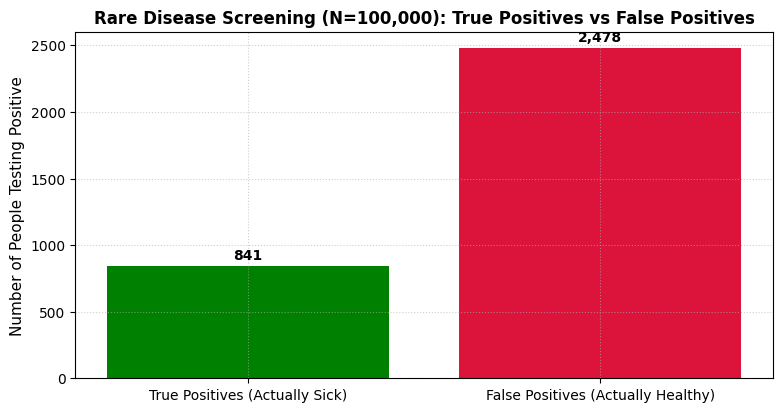

📊 Rare Disease Simulation Breakdown:
   Total Population:                100,000
   True Infected Population:        972
   True Positives (TP):             841
   False Positives (FP):            2,478
   Empirical P(COVID | Positive):   25.34%  (Analytical: 26.12%)


In [4]:
#Start code here..
import matplotlib.pyplot as plt
N_pop = 100000
p_infected = 0.01
tpr_sim, tnr_sim = 0.875, 0.975

#simulate the true health status for each individual in the population
true_health = np.random.binomial(n=1, p=p_infected, size=N_pop)
num_infected = np.sum(true_health == 1)
num_healthy = np.sum(true_health == 0)

test_results = np.zeros(N_pop, dtype=int)

for i in range(N_pop):
    if true_health[i] == 1:
        test_results[i] = np.random.binomial(n=1, p=tpr_sim)
    else:
        test_results[i] = np.random.binomial(n=1, p = (1-tnr_sim))

tp_count = np.sum((true_health == 1) & (test_results == 1))
fp_count = np.sum((true_health == 0) & (test_results == 1))

total_positive_tests = np.sum(test_results==1)
empirical_posterior = tp_count / total_positive_tests

#End code here..

# Bar Plot Visualization
plt.figure(figsize=(9, 4.5))
plt.bar(['True Positives (Actually Sick)', 'False Positives (Actually Healthy)'], [tp_count, fp_count], color=['green', 'crimson'])
plt.ylabel('Number of People Testing Positive', fontsize=11)
plt.title(f'Rare Disease Screening (N={N_pop:,}): True Positives vs False Positives', fontweight='bold')
plt.text(0, tp_count + 50, f'{tp_count:,}', ha='center', fontweight='bold')
plt.text(1, fp_count + 50, f'{fp_count:,}', ha='center', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("📊 Rare Disease Simulation Breakdown:")
print(f"   Total Population:                {N_pop:,}")
print(f"   True Infected Population:        {num_infected:,}")
print(f"   True Positives (TP):             {tp_count:,}")
print(f"   False Positives (FP):            {fp_count:,}")
print(f"   Empirical P(COVID | Positive):   {empirical_posterior*100:.2f}%  (Analytical: 26.12%)")


## 4️⃣ The Monty Hall Paradox: Proof & Monte Carlo Simulation

### 4.1 Problem Setup & Rules
1. Three closed doors $\{1, 2, 3\}$. A car is randomly placed behind one door ($H_i$: Car behind door $i$). Prior $P(H_1) = P(H_2) = P(H_3) = 1/3$.
2. Player selects **Door 1**.
3. Host (Monty Hall) opens an unchosen door that contains NO car. Suppose Monty opens **Door 3** ($Y=3$).
4. Player is offered a choice: **Stick** with Door 1 or **Switch** to Door 2.

### 4.2 Bayesian Proof
Host Observation Likelihoods $P(Y=3 \mid H_i)$:
- If $H_1$ (Car is behind Door 1): Host can open Door 2 or Door 3. $P(Y=3 \mid H_1) = 1/2$.
- If $H_2$ (Car is behind Door 2): Host CANNOT open Door 2 (has car) or Door 1 (player chose). Host is forced to open Door 3. $P(Y=3 \mid H_2) = 1$.
- If $H_3$ (Car is behind Door 3): Host CANNOT reveal the car. $P(Y=3 \mid H_3) = 0$.

Marginal Likelihood (Evidence):
$$P(Y=3) = P(Y=3 \mid H_1)P(H_1) + P(Y=3 \mid H_2)P(H_2) + P(Y=3 \mid H_3)P(H_3) = \left(\frac{1}{2} \cdot \frac{1}{3}\right) + \left(1 \cdot \frac{1}{3}\right) + \left(0 \cdot \frac{1}{3}\right) = \frac{1}{2}$$

Posterior Probabilities:
1. **Sticking to Door 1**: $P(H_1 \mid Y=3) = \frac{P(Y=3 \mid H_1)P(H_1)}{P(Y=3)} = \frac{(1/2)(1/3)}{1/2} = \mathbf{\frac{1}{3} \approx 33.33\%}$
2. **Switching to Door 2**: $P(H_2 \mid Y=3) = \frac{P(Y=3 \mid H_2)P(H_2)}{P(Y=3)} = \frac{(1)(1/3)}{1/2} = \mathbf{\frac{2}{3} \approx 66.67\%}$

**Conclusion**: Switching doors **doubles** the probability of winning the car from $33.3\%$ to $66.7\%$!

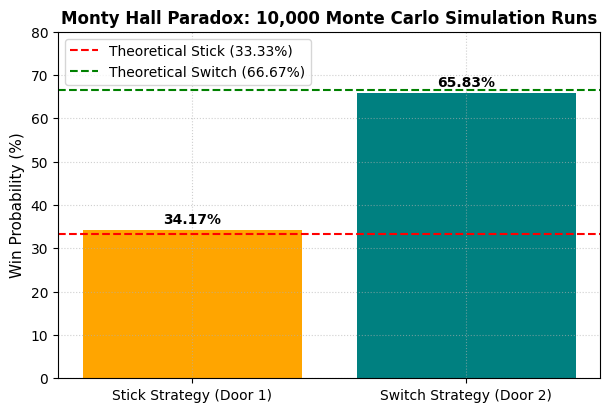

🚗 Monte Carlo Simulation Results (10,000 Games):
   Stick Strategy Win Rate:  34.17%  (Theoretical: 33.33%)
   Switch Strategy Win Rate: 65.83%  (Theoretical: 66.67%)


In [5]:
#Start code here..

#Define a function to simulate the Monty hall game over a specified number of runs
def simulate_monty_hall(num_games = 10000):
    stick_wins = 0 #counter for wins when sticking to the intial choice
    switch_wins = 0 #counter for wins when switching the door

    for _ in range(num_games):
        car_door = np.random.randint(0,3)
        player_pick = np.random.randint(0,3)

        possible_host_doors = [d for d in [0,1,2] if d != player_pick and d != car_door]
        host_door = np.random.choice(possible_host_doors)
        switch_pick = [d for d in [0,1,2] if d != player_pick and d != host_door][0]

        #evaluate the outcomes for both strategies
        #if the player's initial pick was the car door, then it's a win for the 'stick' strategy
        if player_pick == car_door:
            stick_wins += 1
        if switch_pick == car_door:
            switch_wins += 1

    #calculate the win rates
    return stick_wins / num_games, switch_wins / num_games

#run the simulation for 10,000 games
stick_win_rate, switch_win_rate = simulate_monty_hall(num_games = 10000)
#End code here..
# Plotting Simulation Results
plt.figure(figsize=(7, 4.5))
plt.bar(['Stick Strategy (Door 1)', 'Switch Strategy (Door 2)'], [stick_win_rate*100, switch_win_rate*100], color=['orange', 'teal'])
plt.ylabel('Win Probability (%)', fontsize=11)
plt.title('Monty Hall Paradox: 10,000 Monte Carlo Simulation Runs', fontweight='bold')
plt.axhline(33.33, color='red', linestyle='--', label='Theoretical Stick (33.33%)')
plt.axhline(66.67, color='green', linestyle='--', label='Theoretical Switch (66.67%)')
plt.text(0, stick_win_rate*100 + 1.5, f'{stick_win_rate*100:.2f}%', ha='center', fontweight='bold')
plt.text(1, switch_win_rate*100 + 1.5, f'{switch_win_rate*100:.2f}%', ha='center', fontweight='bold')
plt.ylim(0, 80)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"🚗 Monte Carlo Simulation Results (10,000 Games):")
print(f"   Stick Strategy Win Rate:  {stick_win_rate*100:.2f}%  (Theoretical: 33.33%)")
print(f"   Switch Strategy Win Rate: {switch_win_rate*100:.2f}%  (Theoretical: 66.67%)")


## 5️⃣ Inverse Problems vs. Forward Models

### 5.1 Conceptual Definitions
- **Forward Model ($H \to Y$)**: Simulates physical or sensor observations $Y$ given known system state $H$. $P(Y \mid H)$ is deterministic or well-posed.
- **Inverse Problem ($Y \to H$)**: Infers the underlying hidden state $H$ from observed sensor data $Y$. Inverting $Y \to H$ via $P(H \mid Y)$ is often ill-posed, requiring Bayesian priors to regularize ambiguous solutions.

### 5.2 Computer Vision 2D-to-3D Un-projection Example
A 2D square image projection $Y$ can originate from multiple 3D hidden shapes $H$ (a 3D cube, a pyramid viewed from bottom, or a cylinder). The prior $P(H)$ assigns higher weight to natural 3D geometric shapes.

In [6]:
#Start code here...
#define the possible 3D shape hypothesis (hidden states)
shapes = ['3D Cube', '3D pyramid', '3D cylinder', 'Flat 2D sheet']
#the likelihood P(2D square projection | 3D shape)
#the likelihoods or the probabilities of observing a 2d square projection given a 3d shape
likelihoods_2d = np.array([0.95, 0.80, 0.70, 0.99])
#define the prior probabilities p(3d shape)
#these priors reflect the assumed natural scene statistics
priors_3d = np.array([0.60, 0.25, 0.10, 0.05])
unnorm_post = likelihoods_2d * priors_3d
posterior_3d = unnorm_post / np.sum(unnorm_post)

df_inverse = pd.DataFrame({
      '3D Shape hypothesis (H)': shapes,
      'Prior (P(H))': priors_3d,
      'Likelihood (P(Y|H))': likelihoods_2d,
      'Posterior P(H|2D image)' : posterior_3d.round(4)
})

print("Inverse computer vision problem (inferring 3d geometry from 2d image )")
print(df_inverse.to_string(index=False))
#End code here..

Inverse computer vision problem (inferring 3d geometry from 2d image )
3D Shape hypothesis (H)  Prior (P(H))  Likelihood (P(Y|H))  Posterior P(H|2D image)
                3D Cube          0.60                 0.95                   0.6408
             3D pyramid          0.25                 0.80                   0.2248
            3D cylinder          0.10                 0.70                   0.0787
          Flat 2D sheet          0.05                 0.99                   0.0556


## 6️⃣ Master Summary Table
Below is a structured summary of all core concepts covered in Lecture 6.

In [7]:
# Master Concept Summary Table
summary_data = {
    "Concept": [
        "Bayesian Inference",
        "Prior Distribution P(H)",
        "Likelihood P(Y|H)",
        "Posterior Distribution P(H|Y)",
        "Sensitivity (TPR)",
        "Specificity (TNR)",
        "Rare Disease Paradox",
        "Monty Hall Paradox",
        "Inverse Problem"
    ],
    "Mathematical Formulation": [
        "P(H|Y) = P(Y|H)P(H) / P(Y)",
        "P(H=h) over hidden states",
        "P(Y=y | H=h)",
        "Posterior ∝ Prior * Likelihood",
        "P(Y=1 | H=1)",
        "P(Y=0 | H=0)",
        "P(H=1 | Y=1) = TP / (TP + FP) ≈ 26%",
        "P(H_stick|Y=3)=1/3 vs P(H_switch|Y=3)=2/3",
        "Inverting Forward Model H->Y to Y->H"
    ],
    "Key Takeaway / Practical Application": [
        "Generalizing from data to update belief distributions",
        "Initial belief before observing new evidence",
        "Observation model mapping hidden state to data",
        "Updated belief after integrating evidence",
        "Proportion of sick patients correctly identified",
        "Proportion of healthy patients correctly identified",
        "High specificity tests still yield low posterior for rare diseases",
        "Switching doors doubles win chance from 33.3% to 66.7%",
        "Ill-posed 2D-to-3D vision & natural language understanding"
    ]
}

df_master_l6 = pd.DataFrame(summary_data)
print("📌 Lecture 6 Master Summary Table:")
print(df_master_l6.to_string(index=False))


📌 Lecture 6 Master Summary Table:
                      Concept                  Mathematical Formulation                               Key Takeaway / Practical Application
           Bayesian Inference                P(H|Y) = P(Y|H)P(H) / P(Y)              Generalizing from data to update belief distributions
      Prior Distribution P(H)                 P(H=h) over hidden states                       Initial belief before observing new evidence
            Likelihood P(Y|H)                              P(Y=y | H=h)                     Observation model mapping hidden state to data
Posterior Distribution P(H|Y)            Posterior ∝ Prior * Likelihood                          Updated belief after integrating evidence
            Sensitivity (TPR)                              P(Y=1 | H=1)                   Proportion of sick patients correctly identified
            Specificity (TNR)                              P(Y=0 | H=0)                Proportion of healthy patients correctly iden